In [ ]:
# Levi Félix Barbosa - 579420

import numpy as np 
import matplotlib.pyplot as plt  

cancer = np.genfromtxt('breastcancer.csv', delimiter=',')

X_puro = cancer[:,:-1]
y_puro = cancer[:,-1]

N = len(X_puro)

np.random.seed(42)
indices = np.random.permutation(N)
X = X_puro[indices]
y = y_puro[indices]

tam_treino = int(0.8*N)
tam_teste = N - tam_treino

X_treino = X[:tam_treino]
y_treino = y[:tam_treino]

X_teste = X[tam_treino:]
y_teste = y[tam_treino:]

In [ ]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def treinar_reg_log(X, y, alpha, lambd):

    w = np.zeros(X.shape[1])
    b = 0
    loss_hist = []
    for t in range(1, 5000):
        z = X @ w + b
        y_pred = sigmoid(z)
        m = len(X)
        
        y_pred_ok = np.clip(y_pred, 1e-15, 1 - 1e-15)
        loss = -np.mean(y * np.log(y_pred_ok) + (1 - y) * np.log(1 - y_pred_ok)) + lambd * np.sum(w**2) / (2*m)
        loss_hist.append(loss)

        w = w - alpha *( X.T @ (y_pred - y) )/ m - alpha*lambd* w / m
        b = b - alpha * np.mean(y_pred - y)
    
    return w,b, loss_hist
    

def k_fold_split(X, y, k, alpha, lambd):
   
    indices_kfold = np.arange(len(X))
    folds = np.array_split(indices_kfold, k)
    
    resultados = []
    resultados_classe0 = []
    resultados_classe1 = []

    for i in range(k):
        
        val_idx = folds[i]
        
        treino_idx = np.concatenate([folds[j] for j in range(k) if j != i])
        
        X_treinov_puro, X_val_puro = X[treino_idx], X[val_idx]
        y_treinov, y_val = y[treino_idx], y[val_idx]
        m = len(X_treinov_puro)

        media_treino = np.mean(X_treinov_puro, axis=0)
        desvio_treino = np.std(X_treinov_puro, axis=0)
        
        
        X_treinov = (X_treinov_puro - media_treino) / desvio_treino
        X_val = (X_val_puro - media_treino) / desvio_treino
                
        # --- aqui entra o modelo ---  estou treinando com X_treinov e y_treinov

        w, b, loss_hist = treinar_reg_log(X_treinov, y_treinov, alpha, lambd)

        y_prob_val = sigmoid(X_val @ w + b)
        y_pred_val = (y_prob_val >= 0.5).astype(int)

        # acuracia global
        acc = np.mean(y_pred_val == y_val)
        resultados.append(acc)

        # acuracia classe 0
        
        classezero = (y_val == 0)
        if np.sum(classezero) > 0: 
            acc_c0 = np.mean(y_pred_val[classezero] == y_val[classezero])
            resultados_classe0.append(acc_c0)
        
        # acuracia classe 1 

        classeum = (y_val == 1)
        if np.sum(classeum) > 0:
            acc_c1 = np.mean(y_pred_val[classeum] == y_val[classeum])
            resultados_classe1.append(acc_c1)
    
    media = np.mean(resultados)
    desvio = np.std(resultados)

    mediac0 = np.mean(resultados_classe0) 
    desvioc0 = np.std(resultados_classe0)

    mediac1 = np.mean(resultados_classe1)
    desvioc1 = np.std(resultados_classe1)

    
    return media, desvio, mediac0, desvioc0, mediac1, desvioc1


# agora, o grid search
alpha_lista = [0.001, 0.01, 0.1, 1.0]
lambd_lista = [0.001, 0.01, 0.1, 1.0, 10.0]

print('Regressão Logística \n')

teste = []
for i in alpha_lista:
    for j in lambd_lista:
        acc, des, acc0, des0, acc1, des1 = k_fold_split(X_treino, y_treino, 10, i, j)
        teste.append((acc, des, acc0, des0, acc1, des1, i, j))
        print(f'alpha: {i}, lambda: {j}, acurácia média: {acc:.4f}, desvio padrão: {des:.4f}, acurácia classe 0: {acc0:.4f}, desvio classe 0: {des0:.4f}, acurácia classe 1: {acc1:.4f}, desvio classe 1: {des1:.4f}')

teste.sort(key=lambda x: x[0], reverse=True)
melhor_alpha = teste[0][6]
melhor_lambda = teste[0][7]
print('\n')
print(f'Melhor alpha: {melhor_alpha}, Melhor lambda: {melhor_lambda}, acurácia média: {teste[0][0]:.4f}, desvio padrão: {teste[0][1]:.4f}, acurácia classe 0: {teste[0][2]:.4f}, desvio classe 0: {teste[0][3]:.4f}, acurácia classe 1: {teste[0][4]:.4f}, desvio classe 1: {teste[0][5]:.4f}')


alpha: 0.001, lambda: 0.001, acurácia média: 0.9757, desvio padrão: 0.0184, acurácia classe 0: 0.9867, desvio classe 0: 0.0213, acurácia classe 1: 0.9576, desvio classe 1: 0.0480
alpha: 0.001, lambda: 0.01, acurácia média: 0.9757, desvio padrão: 0.0184, acurácia classe 0: 0.9867, desvio classe 0: 0.0213, acurácia classe 1: 0.9576, desvio classe 1: 0.0480
alpha: 0.001, lambda: 0.1, acurácia média: 0.9757, desvio padrão: 0.0184, acurácia classe 0: 0.9867, desvio classe 0: 0.0213, acurácia classe 1: 0.9576, desvio classe 1: 0.0480
alpha: 0.001, lambda: 1.0, acurácia média: 0.9757, desvio padrão: 0.0184, acurácia classe 0: 0.9867, desvio classe 0: 0.0213, acurácia classe 1: 0.9576, desvio classe 1: 0.0480
alpha: 0.001, lambda: 10.0, acurácia média: 0.9736, desvio padrão: 0.0215, acurácia classe 0: 0.9867, desvio classe 0: 0.0213, acurácia classe 1: 0.9499, desvio classe 1: 0.0467
alpha: 0.01, lambda: 0.001, acurácia média: 0.9801, desvio padrão: 0.0252, acurácia classe 0: 0.9899, desvio cl

Acurácia final no conjunto de Teste: 0.9649


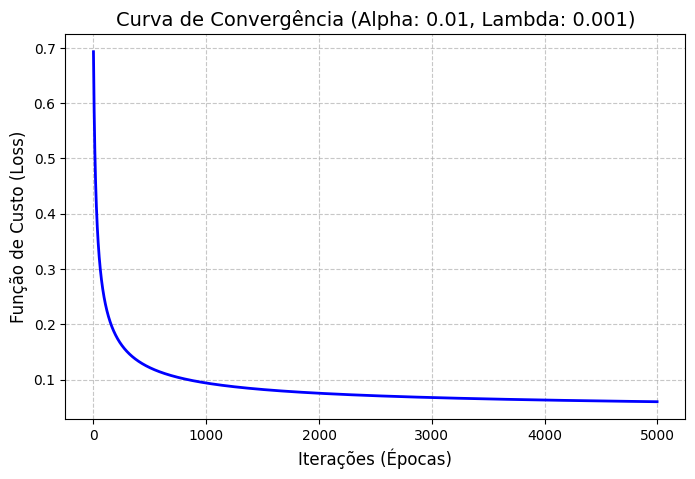

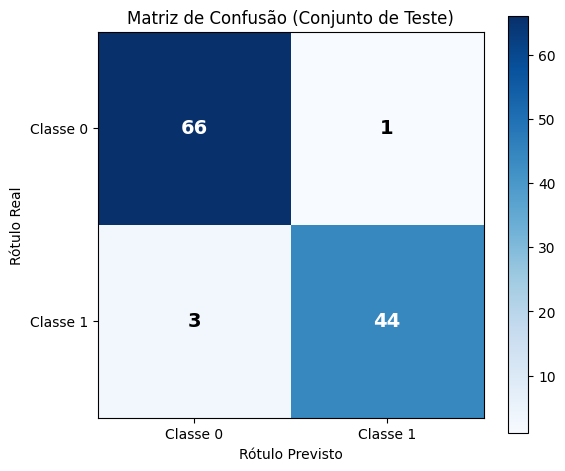

In [ ]:
# agora vamos treinar o modelo todo com esse alpha e esse lambda

X_treino_norm = (X_treino - np.mean(X_treino, axis=0)) / np.std(X_treino, axis=0)
X_teste_norm = (X_teste - np.mean(X_treino, axis=0)) / np.std(X_treino, axis=0)

w_final, b_final, loss_hist = treinar_reg_log(X_treino_norm, y_treino, melhor_alpha, melhor_lambda)

y_prob_teste = sigmoid(X_teste_norm @ w_final + b_final)
y_pred_teste = (y_prob_teste >= 0.5).astype(int)
acc_final = np.mean(y_pred_teste == y_teste)

print('(Regressão Logística) \n')
print(f'Acurácia final no conjunto de Teste: {acc_final:.4f}')


plt.figure(figsize=(8, 5)) 
plt.plot(loss_hist, color='blue', linewidth=2)
plt.title(f'Curva de Convergência (Alpha: {melhor_alpha}, Lambda: {melhor_lambda})', fontsize=14)
plt.xlabel('Iterações (Épocas)', fontsize=12)
plt.ylabel('Função de Custo (Loss)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

VP = np.sum((y_pred_teste == 1) & (y_teste == 1)) 
VN = np.sum((y_pred_teste == 0) & (y_teste == 0)) 
FP = np.sum((y_pred_teste == 1) & (y_teste == 0)) 
FN = np.sum((y_pred_teste == 0) & (y_teste == 1)) 


matriz_confusao = np.array([[VN, FP], 
                            [FN, VP]])


fig, ax = plt.subplots(figsize=(6, 5))


im = ax.imshow(matriz_confusao, interpolation='nearest', cmap=plt.cm.Blues)
ax.figure.colorbar(im, ax=ax) 


classes = ['Classe 0', 'Classe 1']
ax.set(xticks=np.arange(matriz_confusao.shape[1]),
       yticks=np.arange(matriz_confusao.shape[0]),
       xticklabels=classes, yticklabels=classes,
       title='Matriz de Confusão (Conjunto de Teste)',
       ylabel='Rótulo Real',
       xlabel='Rótulo Previsto')


thresh = matriz_confusao.max() / 2.
for i in range(matriz_confusao.shape[0]):
    for j in range(matriz_confusao.shape[1]):
        ax.text(j, i, format(matriz_confusao[i, j], 'd'),
                ha="center", va="center",
                color="white" if matriz_confusao[i, j] > thresh else "black",
                fontsize=14, weight='bold')

fig.tight_layout()
plt.show()

Análise do Discriminante Gaussiano (GDA) 

Resultados da Validação Cruzada:
Acurácia Global:   Média = 0.9493 | Desvio = 0.0281
Acurácia Classe 0: Média = 0.9935 | Desvio = 0.0129
Acurácia Classe 1: Média = 0.8704 | Desvio = 0.0849

Acurácia final no conjunto de Teste: 0.9561


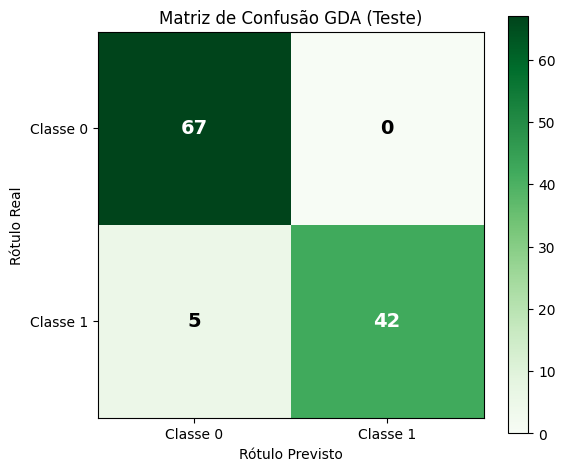

In [ ]:
# agora, vamos ao GDA

def treinar_gda(X, y):

    m, n = X.shape

    X0 = X[y == 0]
    X1 = X[y == 1]

    phi = len(X1) / m

    mu0 = np.mean(X0, axis=0)
    mu1 = np.mean(X1, axis=0)

    # matriz de covariância (sigma)

    X0_centr = X0 - mu0
    X1_centr = X1 - mu1
    
    # juntamos pra calcular a covariância global
    X_centr = np.vstack((X0_centr, X1_centr))
    
    sigma = (X_centr.T @ X_centr) / m

    # prevenir erros 
    sigma += np.eye(n) * 1e-8

    return phi, mu0, mu1, sigma

def prever_gda(X, phi, mu0, mu1, sigma):
    
    sigma_inv = np.linalg.inv(sigma)

    diff0 = X - mu0
    
    dist0 = np.sum((diff0 @ sigma_inv) * diff0, axis=1) 
    log_p0 = -0.5 * dist0 + np.log(1 - phi)

    
    diff1 = X - mu1
    dist1 = np.sum((diff1 @ sigma_inv) * diff1, axis=1)
    log_p1 = -0.5 * dist1 + np.log(phi)

    
    return (log_p1 >= log_p0).astype(int)

def k_fold_gda(X, y, k):
    
    indices_kfold = np.arange(len(X))
    folds = np.array_split(indices_kfold, k)
    
    resultados = []
    resultados_classe0 = []
    resultados_classe1 = []

    for i in range(k):
        val_idx = folds[i]
        treino_idx = np.concatenate([folds[j] for j in range(k) if j != i])
        
        X_treinov_puro, X_val_puro = X[treino_idx], X[val_idx]
        y_treinov, y_val = y[treino_idx], y[val_idx]

        media_treino = np.mean(X_treinov_puro, axis=0)
        desvio_treino = np.std(X_treinov_puro, axis=0)
        X_treinov = (X_treinov_puro - media_treino) / desvio_treino
        X_val = (X_val_puro - media_treino) / desvio_treino
                
        # agora vamos treinar o modelo
        phi, mu0, mu1, sigma = treinar_gda(X_treinov, y_treinov)

        
        y_pred_val = prever_gda(X_val, phi, mu0, mu1, sigma)

        
        acc = np.mean(y_pred_val == y_val)
        resultados.append(acc)

        classezero = (y_val == 0)
        if np.sum(classezero) > 0: 
            acc_c0 = np.mean(y_pred_val[classezero] == y_val[classezero])
            resultados_classe0.append(acc_c0)
        
        classeum = (y_val == 1)
        if np.sum(classeum) > 0:
            acc_c1 = np.mean(y_pred_val[classeum] == y_val[classeum])
            resultados_classe1.append(acc_c1)
    
    media = np.mean(resultados)
    desvio = np.std(resultados)
    mediac0 = np.mean(resultados_classe0) 
    desvioc0 = np.std(resultados_classe0)
    mediac1 = np.mean(resultados_classe1)
    desvioc1 = np.std(resultados_classe1)
    
    return media, desvio, mediac0, desvioc0, mediac1, desvioc1

# avaliações finais


acc, des, acc0, des0, acc1, des1 = k_fold_gda(X_treino, y_treino, 10)

print('Análise do Discriminante Gaussiano (GDA) \n')
print("Resultados da Validação Cruzada:")
print(f"Acurácia Global:   Média = {acc:.4f} | Desvio = {des:.4f}")
print(f"Acurácia Classe 0: Média = {acc0:.4f} | Desvio = {des0:.4f}")
print(f"Acurácia Classe 1: Média = {acc1:.4f} | Desvio = {des1:.4f}")

# agora, treinando tudo para o teste
X_treino_norm = (X_treino - np.mean(X_treino, axis=0)) / np.std(X_treino, axis=0)
X_teste_norm = (X_teste - np.mean(X_treino, axis=0)) / np.std(X_treino, axis=0)

phi_final, mu0_final, mu1_final, sigma_final = treinar_gda(X_treino_norm, y_treino)

y_pred_teste = prever_gda(X_teste_norm, phi_final, mu0_final, mu1_final, sigma_final)
acc_final = np.mean(y_pred_teste == y_teste)

print(f"\nAcurácia final no conjunto de Teste: {acc_final:.4f}")


VP = np.sum((y_pred_teste == 1) & (y_teste == 1))
VN = np.sum((y_pred_teste == 0) & (y_teste == 0))
FP = np.sum((y_pred_teste == 1) & (y_teste == 0))
FN = np.sum((y_pred_teste == 0) & (y_teste == 1))

matriz_confusao = np.array([[VN, FP], [FN, VP]])

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(matriz_confusao, interpolation='nearest', cmap=plt.cm.Greens) 
ax.figure.colorbar(im, ax=ax)
classes = ['Classe 0', 'Classe 1']
ax.set(xticks=np.arange(matriz_confusao.shape[1]), yticks=np.arange(matriz_confusao.shape[0]),
       xticklabels=classes, yticklabels=classes, title='Matriz de Confusão GDA (Teste)', ylabel='Rótulo Real', xlabel='Rótulo Previsto')

thresh = matriz_confusao.max() / 2.
for i in range(matriz_confusao.shape[0]):
    for j in range(matriz_confusao.shape[1]):
        ax.text(j, i, format(matriz_confusao[i, j], 'd'), ha="center", va="center",
                color="white" if matriz_confusao[i, j] > thresh else "black", fontsize=14, weight='bold')
fig.tight_layout()
plt.show()

Naive Bayes Gaussiano 

Resultados:
Acurácia Global:   Média = 0.9384 | Desvio = 0.0290
Acurácia Classe 0: Média = 0.9550 | Desvio = 0.0392
Acurácia Classe 1: Média = 0.9060 | Desvio = 0.0625

Acurácia final no conjunto de Teste: 0.9298


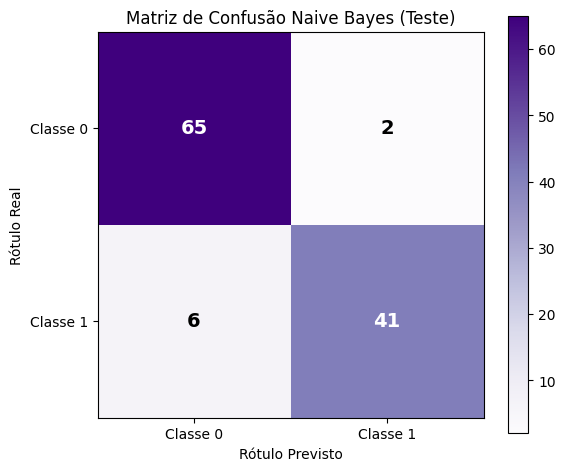

In [ ]:
# agora, vez do Naive Bayes Gaussiano

def treinar_naive_bayes(X, y):

    m, n = X.shape

    X0 = X[y == 0]
    X1 = X[y == 1]

    phi = len(X1) / m

    mu0 = np.mean(X0, axis=0)
    mu1 = np.mean(X1, axis=0)

    var0 = np.var(X0, axis=0)
    var1 = np.var(X1, axis=0)

    return phi, mu0, mu1, var0, var1

def prever_naive_bayes(X, phi, mu0, mu1, var0, var1):
    
    # classe 0
    log_p0_x = -0.5 * np.sum(np.log(2 * np.pi * var0) + ((X - mu0)**2) / var0, axis=1)
    log_p0 = log_p0_x + np.log(1 - phi)

    # classe 1
    log_p1_x = -0.5 * np.sum(np.log(2 * np.pi * var1) + ((X - mu1)**2) / var1, axis=1)
    log_p1 = log_p1_x + np.log(phi)

    return (log_p1 >= log_p0).astype(int)

def k_fold_nb(X, y, k):
    indices_kfold = np.arange(len(X))
    folds = np.array_split(indices_kfold, k)
    
    resultados, resultados_classe0, resultados_classe1 = [], [], []

    for i in range(k):
        val_idx = folds[i]
        treino_idx = np.concatenate([folds[j] for j in range(k) if j != i])
        
        X_treinov_puro, X_val_puro = X[treino_idx], X[val_idx]
        y_treinov, y_val = y[treino_idx], y[val_idx]


        media_treino = np.mean(X_treinov_puro, axis=0)
        desvio_treino = np.std(X_treinov_puro, axis=0)
        X_treinov = (X_treinov_puro - media_treino) / desvio_treino
        X_val = (X_val_puro - media_treino) / desvio_treino
                
        phi, mu0, mu1, var0, var1 = treinar_naive_bayes(X_treinov, y_treinov)

        y_pred_val = prever_naive_bayes(X_val, phi, mu0, mu1, var0, var1)

        acc = np.mean(y_pred_val == y_val)
        resultados.append(acc)

        classezero = (y_val == 0)
        if np.sum(classezero) > 0: 
            resultados_classe0.append(np.mean(y_pred_val[classezero] == y_val[classezero]))
        
        classeum = (y_val == 1)
        if np.sum(classeum) > 0:
            resultados_classe1.append(np.mean(y_pred_val[classeum] == y_val[classeum]))
    
    return (np.mean(resultados), np.std(resultados), 
            np.mean(resultados_classe0), np.std(resultados_classe0), 
            np.mean(resultados_classe1), np.std(resultados_classe1))

# avaliações


acc, des, acc0, des0, acc1, des1 = k_fold_nb(X_treino, y_treino, 10)

print('Naive Bayes Gaussiano \n')
print("Resultados:")
print(f"Acurácia Global:   Média = {acc:.4f} | Desvio = {des:.4f}")
print(f"Acurácia Classe 0: Média = {acc0:.4f} | Desvio = {des0:.4f}")
print(f"Acurácia Classe 1: Média = {acc1:.4f} | Desvio = {des1:.4f}")

# agora, treinando para o teste
X_treino_norm = (X_treino - np.mean(X_treino, axis=0)) / np.std(X_treino, axis=0)
X_teste_norm = (X_teste - np.mean(X_treino, axis=0)) / np.std(X_treino, axis=0)

phi_final, mu0_final, mu1_final, var0_final, var1_final = treinar_naive_bayes(X_treino_norm, y_treino)

y_pred_teste = prever_naive_bayes(X_teste_norm, phi_final, mu0_final, mu1_final, var0_final, var1_final)
acc_final = np.mean(y_pred_teste == y_teste)

print(f"\nAcurácia final no conjunto de Teste: {acc_final:.4f}")

VP = np.sum((y_pred_teste == 1) & (y_teste == 1))
VN = np.sum((y_pred_teste == 0) & (y_teste == 0))
FP = np.sum((y_pred_teste == 1) & (y_teste == 0))
FN = np.sum((y_pred_teste == 0) & (y_teste == 1))

matriz_confusao = np.array([[VN, FP], [FN, VP]])

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(matriz_confusao, interpolation='nearest', cmap=plt.cm.Purples) 
ax.figure.colorbar(im, ax=ax)
classes = ['Classe 0', 'Classe 1']
ax.set(xticks=np.arange(matriz_confusao.shape[1]), yticks=np.arange(matriz_confusao.shape[0]),
       xticklabels=classes, yticklabels=classes, title='Matriz de Confusão Naive Bayes (Teste)', ylabel='Rótulo Real', xlabel='Rótulo Previsto')

thresh = matriz_confusao.max() / 2.
for i in range(matriz_confusao.shape[0]):
    for j in range(matriz_confusao.shape[1]):
        ax.text(j, i, format(matriz_confusao[i, j], 'd'), ha="center", va="center",
                color="white" if matriz_confusao[i, j] > thresh else "black", fontsize=14, weight='bold')
fig.tight_layout()
plt.show()